In [1]:
using JLD2
using Plots
using SpecialFunctions
using Printf
using LaTeXStrings

#!/usr/bin/env julia
using ArgParse
using Dates
using JLD2
using Printf
using Plots

using StatsBase
using Graphs
using SimpleWeightedGraphs
using GraphsMatching

const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

track_domains (generic function with 1 method)

In [2]:
using JLD2

const SWEEP_DIRS = [
    "finer_IsingML_L8,16_sweep",
    "finer_IsingML_L8,16_sweep2",
    "finer_IsingML_L8,16_sweep3",
    "IsingML_L8_sweep",
    "IsingML_L16_sweep",
    "IsingML_L8,24_sweep",
    "IsingML_L12,16_sweep",
    "IsingML_fineq_sweep",
    "MV_L20_sweep",
    "MV_L40_sweep",
    "MV_L60_sweep",
    "MV_L80_sweep",
]

const OUTPUT_ROOT = joinpath(@__DIR__, "..", "output")

function merge_entries(a::NamedTuple, b::NamedTuple)::NamedTuple
    n_a = a.total_samples
    n_b = b.total_samples
    n   = n_a + n_b
    return (
        M1s                 = (n_a .* a.M1s  .+ n_b .* b.M1s)  ./ n,
        M2s                 = (n_a .* a.M2s  .+ n_b .* b.M2s)  ./ n,
        E1s                 = (n_a .* a.E1s  .+ n_b .* b.E1s)  ./ n,
        E2s                 = (n_a .* a.E2s  .+ n_b .* b.E2s)  ./ n,
        instant_failures    = (n_a .* a.instant_failures    .+ n_b .* b.instant_failures)    ./ n,
        cumulative_failures = (n_a .* a.cumulative_failures .+ n_b .* b.cumulative_failures) ./ n,
        Ms_hist             = a.Ms_hist .+ b.Ms_hist,
        Es_hist             = a.Es_hist .+ b.Es_hist,
        total_samples       = n,
        total_time          = a.total_time + b.total_time,
    )
end

collate_files = String[]
for dir in SWEEP_DIRS
    path = joinpath(OUTPUT_ROOT, dir)
    isdir(path) || continue
    for (dirpath, _, filenames) in walkdir(path)
        if "collated_results.jld2" in filenames
            push!(collate_files, joinpath(dirpath, "collated_results.jld2"))
        end
    end
end

all_results = Dict{NTuple{6,Any}, NamedTuple}()
collisions  = 0

for fpath in collate_files
    for ((tag, algo, L, T, p, q, c), entry) in load(fpath, "results")
        key = (algo, L, T, p, q, c)
        if haskey(all_results, key)
            all_results[key] = merge_entries(all_results[key], entry)
            collisions += 1
        else
            all_results[key] = entry
        end
    end
end

println("$(length(all_results)) unique parameter sets, $collisions collision(s) merged.")

36048 unique parameter sets, 1194 collision(s) merged.


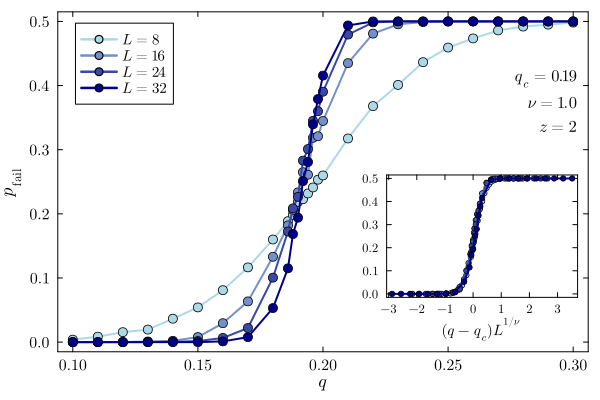

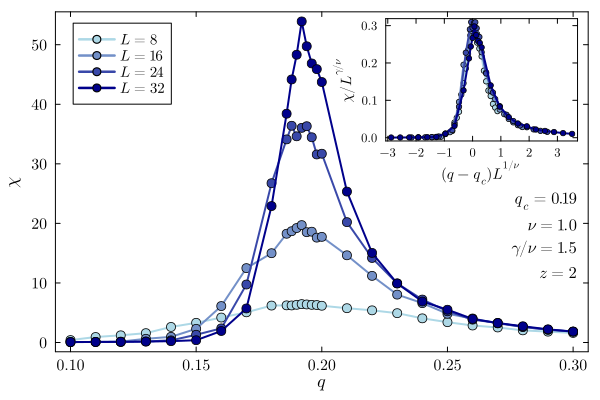

"/Users/jhauser/Code/single_shot/figures/p_005_c_005_fss_chi.pdf"

In [11]:
function fss_explore_fss(all_results;
                          algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor,
                          # ── layout knobs (tinker at bottom) ──
                          legend_cf   = :bottomright,
                          legend_χ    = :none,
                          ins_cf_box  = (0.52, 0.04, 0.40, 0.40),
                          ins_χ_box   = (0.50, 0.04, 0.40, 0.40),
                          ann_y_cf    = 0.95,
                          ann_y_χ     = 0.65,
                          # ── size knobs ──
                          ms_main = 5, ms_ins = 3, lw = 2,
                          fs_main = (tick=10, guide=12, legend=10),
                          fs_ins  = (tick=8,  guide=10, legend=8))
    default(fontfamily = "Computer Modern")
    colors = palette(:blues, length(Ls))
    key(L, q_)         = (algo, L, T_factor*L, p, q_, c)
    has(L, q_)         = haskey(all_results, key(L, q_))
    dat(L, q_, sym)    = all_results[key(L, q_)][sym]
    nsteps(L, q_, sym) = length(dat(L, q_, sym)) - 1

    q_ts_val = if q_ts === :critical
        qs_all = filter(q_ -> all(L -> has(L, q_), Ls), qs)
        isempty(qs_all) && error("No q in qs has data for all L")
        qs_all[argmin(abs.(qs_all .- qc))]
    else
        q_ts
    end

    t_star = minimum(
        nsteps(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_snap = t_frac * t_star

    plt_cf = plot(frame=:box, legend=legend_cf, grid=false,
                  xlabel=L"q",
                  ylabel=L"p_\mathrm{fail}",
                  tickfontsize=fs_main.tick, guidefontsize=fs_main.guide,
                  legendfontsize=fs_main.legend)
    plt_χ  = plot(frame=:box, legend=legend_χ, grid=false,
                  xlabel=L"q",
                  ylabel=L"\chi",
                  tickfontsize=fs_main.tick, guidefontsize=fs_main.guide,
                  legendfontsize=fs_main.legend)

    ins_cf = bbox(ins_cf_box..., :right, :top)
    ins_χ  = bbox(ins_χ_box...,  :right, :top)
    first_inset_cf = true
    first_inset_χ  = true

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        isempty(valid_qs) && continue
        t_idx = round(Int, t_snap * L^z) + 1

        q_vals   = collect(valid_qs)
        cf       = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]/2
        M1v      = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
        M2v      = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
        χv       = L^2 .* (M2v .- M1v.^2)
        x_scaled = (q_vals .- qc) .* L^(1/ν)

        # main: raw data
        plot!(plt_cf, q_vals, cf,  m=ms_main, linewidth=lw, label=L"L = %$(L)", color=col)
        plot!(plt_χ,  q_vals, χv, m=ms_main, linewidth=lw, label=L"L = %$(L)", color=col)

        inset_kw_cf = first_inset_cf ?
            (inset=(1, ins_cf), subplot=2, frame=:box, grid=false, legend=false, title="",
             xlabel=L"(q - q_c) L^{1/\nu}", tickfontsize=fs_ins.tick, guidefontsize=fs_ins.guide,
             legendfontsize=fs_ins.legend) :
            (subplot=2, legend=false)
        inset_kw_χ = first_inset_χ ?
            (inset=(1, ins_χ), subplot=2, frame=:box, grid=false, legend=false, title="",
             xlabel=L"(q - q_c) L^{1/\nu}", ylabel=L"\chi / L^{\gamma/\nu}",
             tickfontsize=fs_ins.tick, guidefontsize=fs_ins.guide,
             legendfontsize=fs_ins.legend) :
            (subplot=2, legend=false)

        # inset: scaling collapse
        plot!(plt_cf, x_scaled, cf,           m=ms_ins, linewidth=lw, color=col; inset_kw_cf...)
        plot!(plt_χ,  x_scaled, χv ./ L^γ_ν, m=ms_ins, linewidth=lw, color=col; inset_kw_χ...)
        first_inset_cf = false
        first_inset_χ  = false
    end

# ── floating parameter label ─────────────────────────────────────────────
    ν_str = isapprox(ν, 4/3) ? "4/3" : string(round(ν, digits=3))
    γ_ν_str = isinteger(γ_ν) ? string(Int(γ_ν)) : string(round(γ_ν, digits=3))
    z_str = isinteger(z)     ? string(Int(z)) : string(round(z, digits=3))

    for plt in [plt_cf]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*ann_y_cf - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt[1], x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    for plt in [plt_χ]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("\\gamma/\\nu = $γ_ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*ann_y_χ - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt[1], x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    p1 = plot(plt_cf, layout=(1,1))
    p2 = plot(plt_χ,  layout=(1,1))
    p1, p2
end
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.05
c        = 0.05
qs       = 0.1:0.001:0.3
qc       = 0.19
q_ts     = :critical
ν        = 1.0
γ_ν      = 1.5
z        = 2.0
t_frac   = 1.0     # 0 = start, 1 = latest time common to all L
T_factor = 20

# ── layout: legend + insets ───────────────────────────────────────────────────
legend_cf  = :topleft                 # legend position, failure-rate plot
legend_χ   = :topleft                     # legend position, χ plot
ins_cf_box = (0.02, 0.48, 0.36, 0.36)     # (x, y, w, h), anchored :right,:top — keep x + w ≤ 1
ins_χ_box  = (0.02, 0.02, 0.36, 0.36)
ann_y_cf   = 0.85                         # vertical anchor of parameter labels
ann_y_χ    = 0.48

# ── sizes ─────────────────────────────────────────────────────────────────────
ms_main = 5;  ms_ins = 3;  lw = 2
fs_main = (tick=10, guide=12, legend=10)
fs_ins  = (tick=8,  guide=10, legend=8)

p1, p2 = fss_explore_fss(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor,
                         legend_cf, legend_χ, ins_cf_box, ins_χ_box, ann_y_cf, ann_y_χ,
                         ms_main, ms_ins, lw, fs_main, fs_ins)
display(p1)
display(p2)

savefig(p1, "../figures/p_005_c_005_fss_pfail.pdf")
savefig(p2, "../figures/p_005_c_005_fss_chi.pdf")

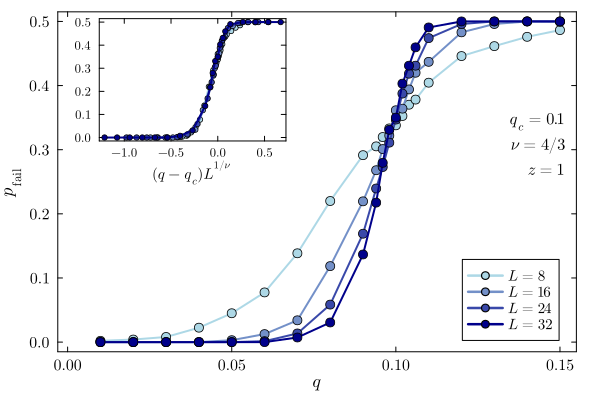

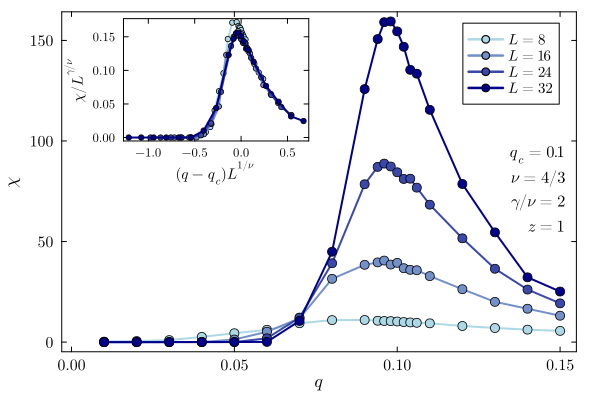

"/Users/jhauser/Code/single_shot/figures/p_03_c_08_fss_chi.pdf"

In [22]:
function fss_explore_fss(all_results;
                          algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor,
                          # ── layout knobs (tinker at bottom) ──
                          legend_cf   = :topleft,
                          legend_χ    = :none,
                          ins_cf_box  = (0.03, 0.05, 0.35, 0.35),
                          ins_χ_box   = (0.03, 0.05, 0.35, 0.35),
                          ann_y_cf    = 0.95,
                          ann_y_χ     = 0.65,
                          # ── size knobs ──
                          ms_main = 5, ms_ins = 3, lw = 2,
                          fs_main = (tick=10, guide=12, legend=10),
                          fs_ins  = (tick=8,  guide=10, legend=8))
    default(fontfamily = "Computer Modern")
    colors = palette(:blues, length(Ls))
    key(L, q_)         = (algo, L, T_factor*L, p, q_, c)
    has(L, q_)         = haskey(all_results, key(L, q_))
    dat(L, q_, sym)    = all_results[key(L, q_)][sym]
    nsteps(L, q_, sym) = length(dat(L, q_, sym)) - 1

    q_ts_val = if q_ts === :critical
        qs_all = filter(q_ -> all(L -> has(L, q_), Ls), qs)
        isempty(qs_all) && error("No q in qs has data for all L")
        qs_all[argmin(abs.(qs_all .- qc))]
    else
        q_ts
    end

    t_star = minimum(
        nsteps(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_snap = t_frac * t_star

    plt_cf = plot(frame=:box, legend=legend_cf, grid=false,
                  xlabel=L"q",
                  ylabel=L"p_\mathrm{fail}",
                  xlims=(-0.003, 0.155), xticks=0:0.05:0.15,
                  right_margin=4Plots.mm,
                  tickfontsize=fs_main.tick, guidefontsize=fs_main.guide,
                  legendfontsize=fs_main.legend)
    plt_χ  = plot(frame=:box, legend=legend_χ, grid=false,
                  xlabel=L"q",
                  ylabel=L"\chi",
                  xlims=(-0.003, 0.155), xticks=0:0.05:0.15,
                  right_margin=4Plots.mm,
                  tickfontsize=fs_main.tick, guidefontsize=fs_main.guide,
                  legendfontsize=fs_main.legend)

    ins_cf = bbox(ins_cf_box..., :right, :top)
    ins_χ  = bbox(ins_χ_box...,  :right, :top)
    first_inset_cf = true
    first_inset_χ  = true

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        isempty(valid_qs) && continue
        t_idx = round(Int, t_snap * L^z) + 1

        q_vals   = collect(valid_qs)
        cf       = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]/2
        M1v      = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
        M2v      = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
        χv       = L^2 .* (M2v .- M1v.^2)
        x_scaled = (q_vals .- qc) .* L^(1/ν)

        # main: raw data
        plot!(plt_cf, q_vals, cf,  m=ms_main, linewidth=lw, label=L"L = %$(L)", color=col)
        plot!(plt_χ,  q_vals, χv, m=ms_main, linewidth=lw, label=L"L = %$(L)", color=col)

        inset_kw_cf = first_inset_cf ?
            (inset=(1, ins_cf), subplot=2, frame=:box, grid=false, legend=false, title="",
             xlabel=L"(q - q_c) L^{1/\nu}",
             tickfontsize=fs_ins.tick, guidefontsize=fs_ins.guide,
             legendfontsize=fs_ins.legend) :
            (subplot=2, legend=false)
        inset_kw_χ = first_inset_χ ?
            (inset=(1, ins_χ), subplot=2, frame=:box, grid=false, legend=false, title="",
             xlabel=L"(q - q_c) L^{1/\nu}", ylabel=L"\chi / L^{\gamma/\nu}",
             tickfontsize=fs_ins.tick, guidefontsize=fs_ins.guide,
             legendfontsize=fs_ins.legend) :
            (subplot=2, legend=false)

        # inset: scaling collapse
        plot!(plt_cf, x_scaled, cf,           m=ms_ins, linewidth=lw, color=col; inset_kw_cf...)
        plot!(plt_χ,  x_scaled, χv ./ L^γ_ν, m=ms_ins, linewidth=lw, color=col; inset_kw_χ...)
        first_inset_cf = false
        first_inset_χ  = false
    end

# ── floating parameter label ─────────────────────────────────────────────
    ν_str = isapprox(ν, 4/3) ? "4/3" : string(round(ν, digits=3))
    γ_ν_str = isinteger(γ_ν) ? string(Int(γ_ν)) : string(round(γ_ν, digits=3))
    z_str = isinteger(z)     ? string(Int(z)) : string(round(z, digits=3))

    for plt in [plt_cf]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*ann_y_cf - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt[1], x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    for plt in [plt_χ]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("\\gamma/\\nu = $γ_ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*ann_y_χ - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt[1], x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    p1 = plot(plt_cf, layout=(1,1))
    p2 = plot(plt_χ,  layout=(1,1))
    p1, p2
end
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.3
c        = 0.8
qs       = 0.01:0.001:0.15
qc       = 0.1
q_ts     =  :critical
ν        = 4/3
γ_ν      = 2.0
z        = 1.0
t_frac   = 0.1     # 0 = start, 1 = latest time common to all L
T_factor = 20

# ── layout: legend + insets ───────────────────────────────────────────────────
legend_cf  = :bottomright                     # legend position, failure-rate plot
legend_χ   = :topright                     # legend position, χ plot
ins_cf_box = (0.56, 0.02, 0.36, 0.36)     # (x, y, w, h), anchored :right,:top — keep x + w ≤ 1
ins_χ_box  = (0.52, 0.02, 0.36, 0.36)
ann_y_cf   = 0.72                  # vertical anchor of parameter labels
ann_y_χ    = 0.62

# ── sizes ─────────────────────────────────────────────────────────────────────
ms_main = 5;  ms_ins = 3;  lw = 2
fs_main = (tick=10, guide=12, legend=10)
fs_ins  = (tick=8,  guide=10, legend=8)

p1, p2 = fss_explore_fss(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor,
                         legend_cf, legend_χ, ins_cf_box, ins_χ_box, ann_y_cf, ann_y_χ,
                         ms_main, ms_ins, lw, fs_main, fs_ins)
display(p1)
display(p2)
savefig(p1, "../figures/p_03_c_08_fss_pfail.pdf")
savefig(p2, "../figures/p_03_c_08_fss_chi.pdf")